# Importing Libraries & Defining paths

In [1]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data/raw"
NB_DIR = f"{BASE_DIR}/notebooks"

import os
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
%pip install osmnx networkx geopandas

In [3]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt

# Casablanca street network

In [4]:
# Define the place to download the street network
place_name = "Casablanca, Morocco"

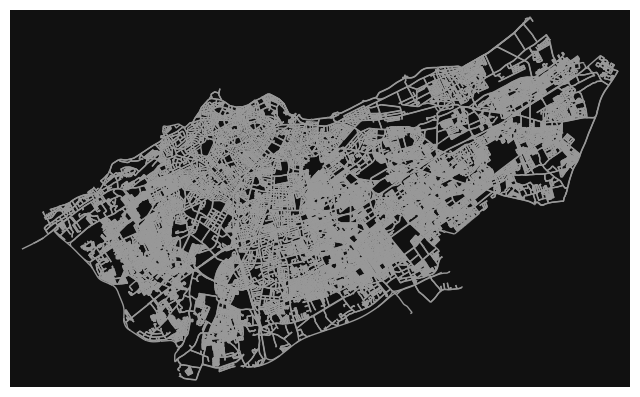

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
# Download the street network
print(f"Downloading street network for {place_name}...")
G = ox.graph_from_place(place_name, network_type='drive')
ox.plot_graph(G, node_size=0)

# Basic Street network Stats

In [ ]:
# what sized area does network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

In [ ]:
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

# Street Centrality

In [ ]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality") # 456m44.2s

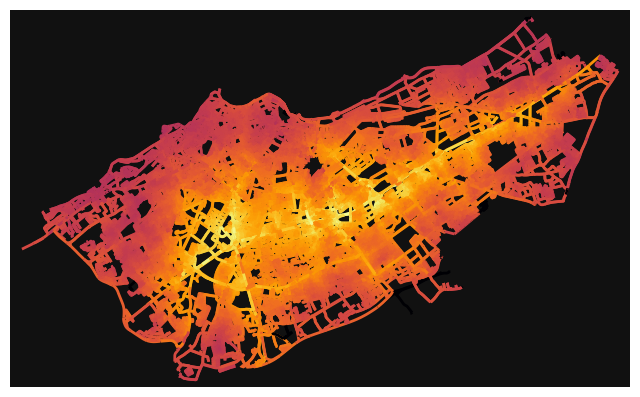

In [9]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

# Hospitals and Bus stops in Casablanca

In [ ]:
# get all hospitals in the area
tags = {"amenity":"hospital"}
hospital_gdf = ox.features.features_from_place(place_name, tags)
hospital_gdf.shape

(46, 32)

In [ ]:
# get all bus stops
tags = {"highway": "bus_stop"}
bus_stop_gdf = ox.features.features_from_place(place_name, tags)
bus_stop_gdf.shape

(1481, 46)

<Axes: >

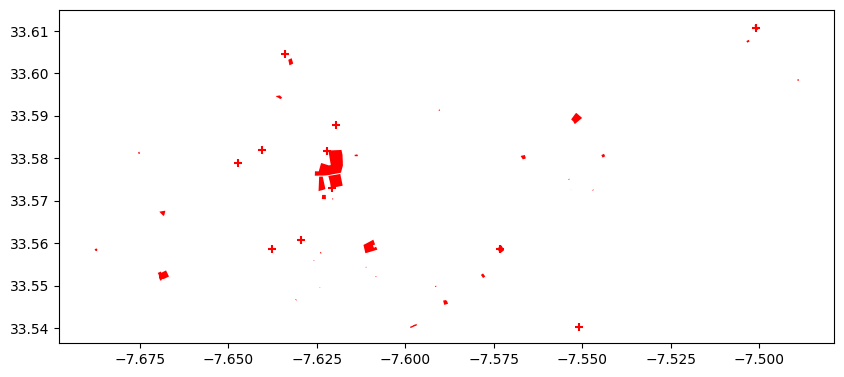

In [28]:
hospital_gdf.plot(figsize=(10,10), color='red', marker='+')

<Axes: >

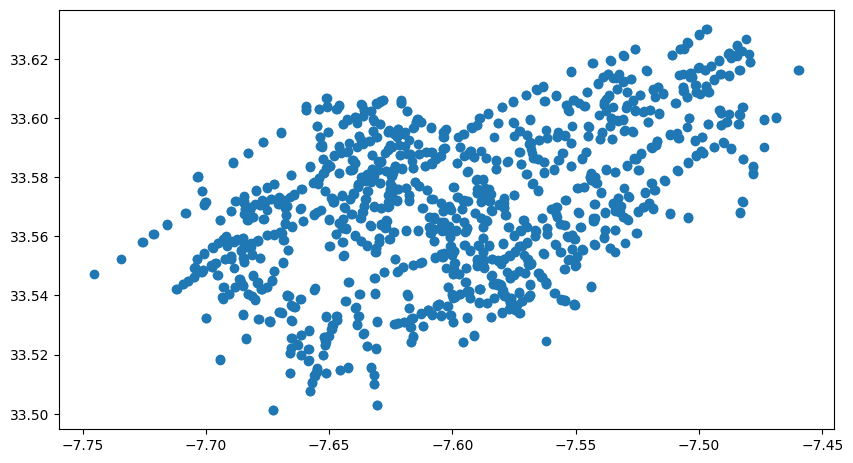

In [23]:
bus_stop_gdf.plot(figsize=(10,10))

C:\Users\afafb\AppData\Local\Temp\ipykernel_6268\458536458.py:17: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


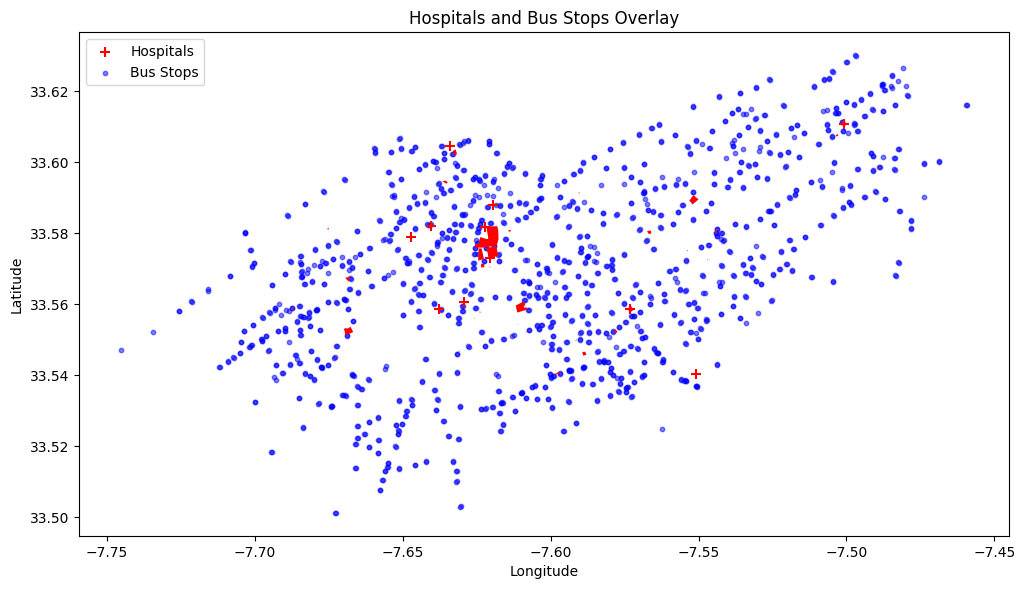

In [ ]:
# Ensure both GDFs use the same CRS
bus_stop_gdf = bus_stop_gdf.to_crs(hospital_gdf.crs)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the first layer (Hospitals)
hospital_gdf.plot(ax=ax, color='red', marker='+', markersize=50, label='Hospitals', zorder=2)

# Plot the second layer (Bus Stops)
bus_stop_gdf.plot(ax=ax, color='blue', marker='o', markersize=10, alpha=0.5, label='Bus Stops', zorder=1)

# Add map details
plt.title("Hospitals and Bus Stops Overlay")
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Convert graph to Geo Dataframe; Export nodes & edges to shapefiles

In [6]:
# Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

In [7]:
# Export shapefiles
print(f"Saving data to {DATA_DIR}...")
nodes.to_file(os.path.join(DATA_DIR, "nodes.shp"))
edges.to_file(os.path.join(DATA_DIR, "edges.shp"))

Saving data to D:/Capstone/capstone_repo/data/raw...


C:\Users\afafb\AppData\Local\Temp\ipykernel_6268\529394631.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file(os.path.join(DATA_DIR, "nodes.shp"))
c:\Users\afafb\AppData\Local\Programs\Python\Python310\lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


# Git

In [ ]:
# git status
# git add .
# git commit -m "Data collection: Downloaded and saved street network for Casablanca, Morocco"
# git push